<a href="https://colab.research.google.com/github/diesalgueiros-wq/E-Commerce-Predictive-Analytics/blob/main/notebooks/02_AI_Models_and_Search_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Conexión con Google Drive
drive.mount('/content/drive')

# 2. Rutas del proyecto
project_path = "/content/drive/MyDrive/TFM_IA_DiegoSalgueiro"
sys.path.append(project_path)

print("Entorno configurado y librerias cargadas correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno configurado y librerias cargadas correctamente.


In [ ]:
# Definición de la ruta del archivo limpio
path_drive = "/content/drive/MyDrive/TFM_IA_DiegoSalgueiro/Online_Retail_Processed.csv"

try:
    customers = pd.read_csv(path_drive)
    print("Confirmacion: Archivo CSV cargado correctamente.")
except Exception:
    print("Aviso: No se encontro el CSV, intentando cargar el XLSX alternativo...")
    path_xlsx = "/content/drive/MyDrive/TFM_IA_DiegoSalgueiro/Online_Retail_Processed.xlsx"
    customers = pd.read_excel(path_xlsx)

# Asegurar formato numérico en la columna de identificación de clientes
customers['CustomerID'] = pd.to_numeric(customers['CustomerID'], errors='coerce')

display(customers.head())

Confirmacion: Archivo CSV cargado correctamente.


,CustomerID,Recency,Frequency,MonetaryValue,ProductVariety,Is_VIP
0,12348.0,74,4,1797.24,22,0
1,12349.0,18,1,1757.55,73,0
2,12350.0,309,1,334.40,17,0
3,12352.0,35,8,2506.04,59,1
4,12353.0,203,1,89.00,4,0


In [ ]:
if 'Is_VIP' not in customers.columns:
    limite_frecuencia = customers['Frequency'].quantile(0.80)
    limite_gasto = customers['MonetaryValue'].quantile(0.80)
    customers['Is_VIP'] = ((customers['Frequency'] > limite_frecuencia) &
                            (customers['MonetaryValue'] > limite_gasto)).astype(int)

columnas_entrada = ['Recency', 'Frequency', 'MonetaryValue']
if 'ProductVariety' in customers.columns:
    columnas_entrada.append('ProductVariety')

X = customers[columnas_entrada]
y_class = customers['Is_VIP']
y_reg = customers['MonetaryValue']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

rf_class = RandomForestClassifier(random_state=42, max_depth=5)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
xgb_class = xgb.XGBClassifier(random_state=42, max_depth=5, eval_metric='logloss')

rf_class.fit(X_train_c, y_train_c)
tree_model.fit(X_train_c, y_train_c)
xgb_class.fit(X_train_c, y_train_c)

pred_rf_c = rf_class.predict(X_test_c)
pred_xgb_c = xgb_class.predict(X_test_c)

tabla_clasificacion = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision (VIP)', 'Recall (VIP)', 'F1-Score'],
    'Random Forest': [
        accuracy_score(y_test_c, pred_rf_c),
        precision_score(y_test_c, pred_rf_c),
        recall_score(y_test_c, pred_rf_c),
        f1_score(y_test_c, pred_rf_c)
    ],
    'XGBoost': [
        accuracy_score(y_test_c, pred_xgb_c),
        precision_score(y_test_c, pred_xgb_c),
        recall_score(y_test_c, pred_xgb_c),
        f1_score(y_test_c, pred_xgb_c)
    ]
}).round(3)

rf_reg = RandomForestRegressor(random_state=42, max_depth=5)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42) # Usado en el buscador

rf_reg.fit(X_train_r, y_train_r)
xgb_model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pred_rf_r = rf_reg.predict(X_test_r)
pred_xgb_r = xgb_model.predict(X_test_r)

tabla_regresion = pd.DataFrame({
    'Metrica': ['R2 Score', 'MAE (GBP)', 'RMSE (GBP)'],
    'Random Forest': [
        r2_score(y_test_r, pred_rf_r),
        mean_absolute_error(y_test_r, pred_rf_r),
        np.sqrt(mean_squared_error(y_test_r, pred_rf_r))
    ],
    'XGBoost': [
        r2_score(y_test_r, pred_xgb_r),
        mean_absolute_error(y_test_r, pred_xgb_r),
        np.sqrt(mean_squared_error(y_test_r, pred_xgb_r))
    ]
}).round(3)

print("=======================================================")
print("TABLA COMPARATIVA: SEGMENTACION VIP (CLASIFICACION)")
print("=======================================================")
display(tabla_clasificacion)

print("\n=======================================================")
print("TABLA COMPARATIVA: PREDICCION DE GASTO (REGRESION)")
print("=======================================================")
display(tabla_regresion)

TABLA COMPARATIVA: SEGMENTACION VIP (CLASIFICACION)


,Metrica,Random Forest,XGBoost
0,Accuracy,1.0,0.997
1,Precision (VIP),1.0,1.000
2,Recall (VIP),1.0,0.979
3,F1-Score,1.0,0.989



TABLA COMPARATIVA: PREDICCION DE GASTO (REGRESION)


,Metrica,Random Forest,XGBoost
0,R2 Score,1.000,1.000
1,MAE (GBP),9.422,4.226
2,RMSE (GBP),12.472,8.564


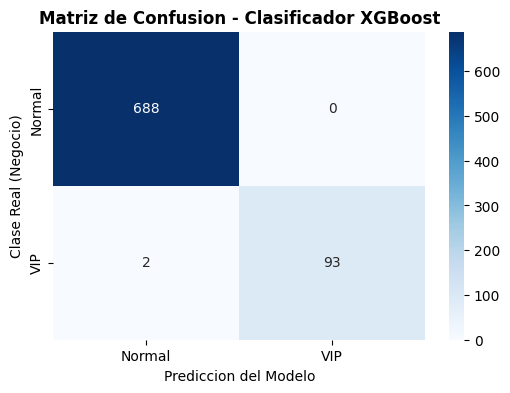

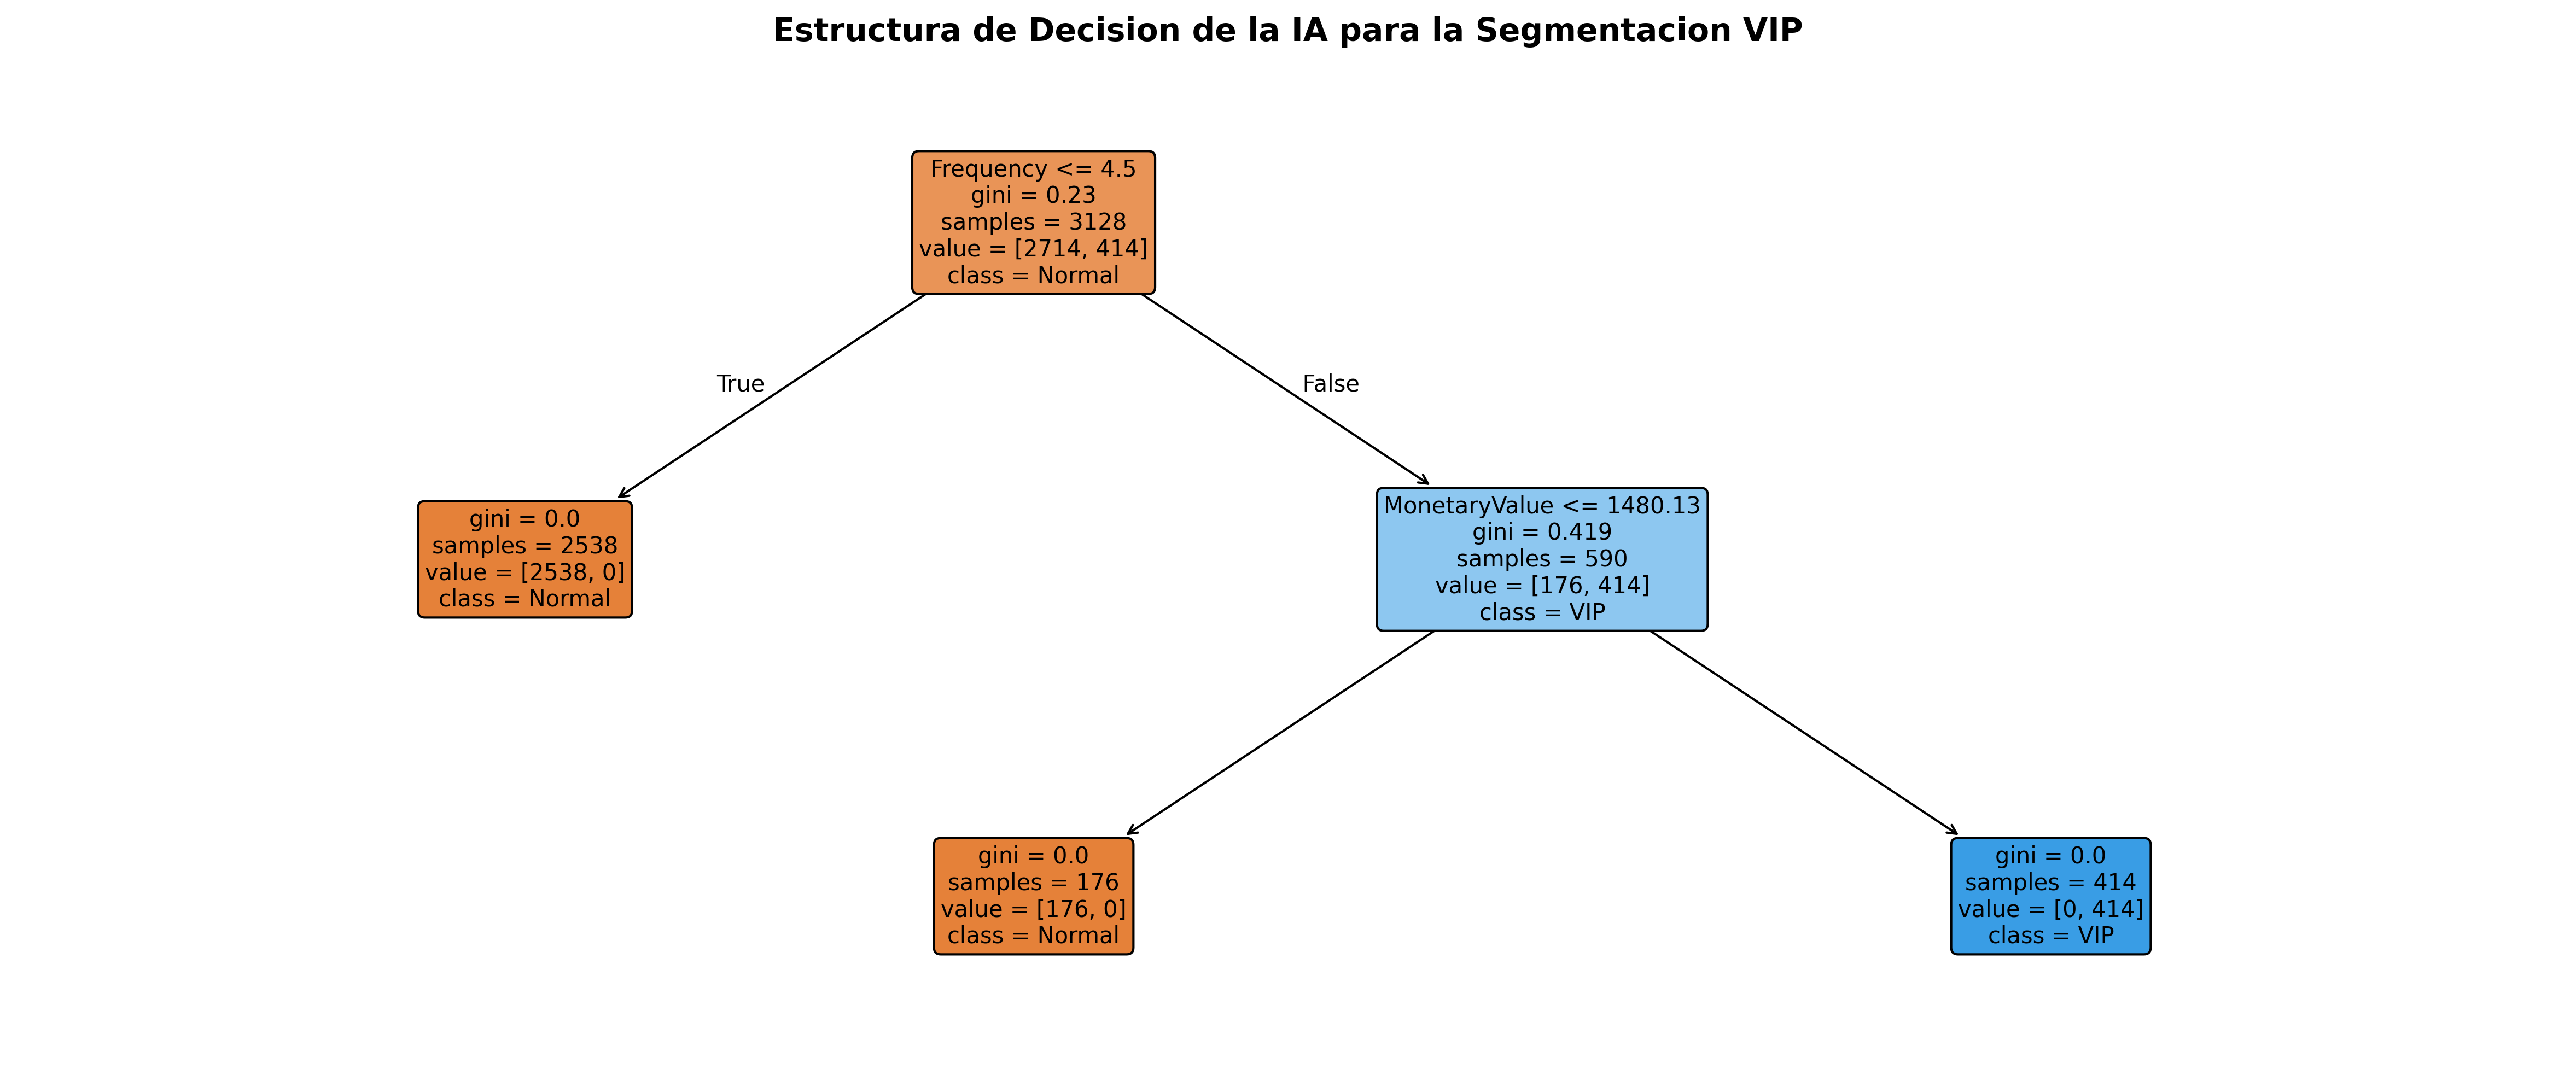

In [ ]:
# 1. Generación de la Matriz de Confusión para el clasificador XGBoost
cm = confusion_matrix(y_test_c, pred_xgb_c)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'VIP'],
    yticklabels=['Normal', 'VIP']
)
plt.title('Matriz de Confusion - Clasificador XGBoost', fontsize=12, fontweight='bold')
plt.xlabel('Prediccion del Modelo')
plt.ylabel('Clase Real (Negocio)')
plt.show()

# 2. Visualización de la estructura lógica del Árbol de Decisión
plt.figure(figsize=(20, 8), dpi=300)
plot_tree(
    tree_model,
    feature_names=X.columns.tolist(),
    class_names=['Normal', 'VIP'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Estructura de Decision de la IA para la Segmentacion VIP', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
def run_analysis(customer_id):
    customer_id = float(customer_id)
    if customer_id not in customers['CustomerID'].values:
        print(f"Aviso: El ID {int(customer_id)} no se encuentra en la base de datos.")
        return


    fila = customers[customers['CustomerID'] == customer_id]


    columnas_ia = ['Recency', 'Frequency', 'MonetaryValue']
    if 'ProductVariety' in customers.columns:
        columnas_ia.append('ProductVariety')

    ai_input = fila[columnas_ia]


    is_vip = tree_model.predict(ai_input)[0]
    pred_spend = xgb_model.predict(ai_input)[0]


    print("\n" + "="*55)
    print(f"      INFORME PREDICTIVO IA PARA EL CLIENTE: {int(customer_id)}")
    print("=======================================================")
    print(f" > Categoria Asignada por IA:       {'VIP' if is_vip == 1 else 'Normal'}")
    print(f" > Gasto Potencial Estimado (VAL):  {pred_spend:.2f} GBP")
    print("-" * 55)


    columnas_mostrar = ['Recency', 'Frequency', 'MonetaryValue']
    if 'ProductVariety' in customers.columns:
        columnas_mostrar.append('ProductVariety')

    display(fila[columnas_mostrar].reset_index(drop=True))
    print("=======================================================")


search_input = widgets.Text(
    placeholder='Ej. 17850',
    description='ID Cliente:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)

button = widgets.Button(description="Analizar Cliente", button_style='success')
out = widgets.Output()

def on_button_clicked(b):
    with out:
        clear_output()
        if search_input.value.lower() == 'exit':
            print("Motor de busqueda detenido.")
            return
        try:
            run_analysis(search_input.value)
        except ValueError:
            print("Por favor, introduce un ID estrictamente numerico.")

button.on_click(on_button_clicked)

print("--- Herramienta Interactiva de Consulta Comercial ---")
print("(Escribe 'exit' en el cuadro y pulsa el boton para apagar)")
display(widgets.HBox([search_input, button]), out)

--- Herramienta Interactiva de Consulta Comercial ---
(Escribe 'exit' en el cuadro y pulsa el boton para apagar)


Output()